<a href="https://colab.research.google.com/github/tirthpatel618/dream-takehome/blob/main/Tirth_Patel_Dream_Takehome_Waterloo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

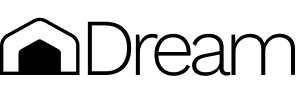
# **Dream Technologies Take-Home Challenge**

**At Dream, we’re building AI tools to make home design faster, cheaper, more enjoyable, and more democratized.** We'd like you to help us with a critical component: making interior layouts not just look good, but work. That means connecting rooms in a logical and usable way. We want you to build an algorithm that places doors between rooms in a house, just like an architect might when turning a layout into a livable space.

---

## The Problem
We've given you three example floorplans in JSON format. Each one defines the house boundary and a set of rooms with labeled functions (e.g. "bedroom", "kitchen"). Your task is to write an algorithm that places doors between rooms; choosing where and how rooms connect, and ensuring the house is traversable and coherent. You’ll implement your solution right here in Colab, and your code should produce door placement output for each sample input. We've given you a rendering utility so you can visualize your results using MatplotLib.

We will test your notebook on three different floorplans than the ones provided, so your algorithm should generalize to new layouts.

---

## The Data

Each floorplan is structured as a JSON object and includes:

`dimensions` *The width and height of the floorplan in feet.*

`exteriorWalls { x, y }` *A list of wall segments, each defined by a start and end point and a thickness.*

`rooms` *A list of rooms. Each of which has:*

`id` *Unique string identifier*

`name` *Display Name(e.g.“Primary Bedroom ”)*

`type` *Room function ( e.g . “bedroom” , “kitchen”)*

`walls` *A list of wall segments defining the room boundary*

Your algorithm will need to determine where rooms share walls and place door(s) appropriately. Room geometry is defined via 2D coordinates in feet; rooms that share wall segments are candidates for connections.

---

## Extra Considerations

While not required, for completeness, your algorithm can also consider:
* Only connect rooms where it makes functional sense
* Include door swing direction (e.g., left-hand vs. right-hand, swing outward vs. inward)
* Use open archways instead of doors for certain room pair
* Avoid unnecessary doors (e.g., bathrooms with three or more doors)

---

## Getting Started

1.  **Work in this colab notebook:** All your solutions, code, and analysis should be done in this notebook
2.  **Add Comments & Explanations:** Please document your thought process, code choices, and any assumptions you make.
3.  **Run All Cells:** Before you submit, ensure all your code runs correctly from top to bottom.
    * Go to `Runtime > Run all`. This helps us verify your solution.


This challenge is designed to be completed directly in Google Colab, and should only take an hour or two. Feel free to use AI coding tools if you'd like.

In [ ]:
# Sample data
floorplan_1 = {
    "id": "1",
    "name": "One Bedroom Apartment",
    "dimensions": {
        "width": 50,  # feet
        "height": 30,  # feet
    },
    "exteriorWalls": [
        {"start": {"x": 0, "y": 0}, "end": {"x": 50, "y": 0}, "thickness": 0.5},
        {"start": {"x": 50, "y": 0}, "end": {"x": 50, "y": 30}, "thickness": 0.5},
        {"start": {"x": 50, "y": 30}, "end": {"x": 0, "y": 30}, "thickness": 0.5},
        {"start": {"x": 0, "y": 30}, "end": {"x": 0, "y": 0}, "thickness": 0.5},
    ],
    "rooms": [
        {
            "id": "kitchen",
            "name": "Kitchen",
            "type": "kitchen",
            "walls": [
                {"start": {"x": 0, "y": 30}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
                {"start": {"x": 20, "y": 30}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
                {"start": {"x": 20, "y": 20}, "end": {"x": 0, "y": 20}, "thickness": 0.3},
                {"start": {"x": 0, "y": 20}, "end": {"x": 0, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "living",
            "name": "Living",
            "type": "living",
            "walls": [
                {"start": {"x": 20, "y": 30}, "end": {"x": 40, "y": 30}, "thickness": 0.3},
                {"start": {"x": 40, "y": 30}, "end": {"x": 40, "y": 20}, "thickness": 0.3},
                {"start": {"x": 40, "y": 20}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
                {"start": {"x": 20, "y": 20}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_1",
            "name": "Bathroom 1",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 20, "y": 20}, "end": {"x": 30, "y": 20}, "thickness": 0.3},
                {"start": {"x": 30, "y": 20}, "end": {"x": 30, "y": 10}, "thickness": 0.3},
                {"start": {"x": 30, "y": 10}, "end": {"x": 20, "y": 10}, "thickness": 0.3},
                {"start": {"x": 20, "y": 10}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
            ],
        },
        {
            "id": "bedroom",
            "name": "Bedroom",
            "type": "bedroom",
            "walls": [
                {"start": {"x": 30, "y": 20}, "end": {"x": 50, "y": 20}, "thickness": 0.3},
                {"start": {"x": 50, "y": 20}, "end": {"x": 50, "y": 10}, "thickness": 0.3},
                {"start": {"x": 50, "y": 10}, "end": {"x": 30, "y": 10}, "thickness": 0.3},
                {"start": {"x": 30, "y": 10}, "end": {"x": 30, "y": 20}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_2",
            "name": "Bathroom 2",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 40, "y": 30}, "end": {"x": 50, "y": 30}, "thickness": 0.3},
                {"start": {"x": 50, "y": 30}, "end": {"x": 50, "y": 20}, "thickness": 0.3},
                {"start": {"x": 50, "y": 20}, "end": {"x": 40, "y": 20}, "thickness": 0.3},
                {"start": {"x": 40, "y": 20}, "end": {"x": 40, "y": 30}, "thickness": 0.3},
            ],
        },
    ],
}
floorplan_3 = {
    "id": "3",
    "name": "Two Bedroom Apartment",
    "dimensions": {
        "width": 40,  # feet
        "height": 30,  # feet
    },
    "exteriorWalls": [
        {"start": {"x": 0, "y": 0}, "end": {"x": 40, "y": 0}, "thickness": 0.5},
        {"start": {"x": 40, "y": 0}, "end": {"x": 40, "y": 30}, "thickness": 0.5},
        {"start": {"x": 40, "y": 30}, "end": {"x": 0, "y": 30}, "thickness": 0.5},
        {"start": {"x": 0, "y": 30}, "end": {"x": 0, "y": 0}, "thickness": 0.5},
    ],
    "rooms": [
        {
            "id": "bedroom_1",
            "name": "Bedroom 1",
            "type": "bedroom",
            "walls": [
                {"start": {"x": 0, "y": 30}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
                {"start": {"x": 20, "y": 30}, "end": {"x": 20, "y": 15}, "thickness": 0.3},
                {"start": {"x": 20, "y": 15}, "end": {"x": 10, "y": 15}, "thickness": 0.3},
                {"start": {"x": 10, "y": 15}, "end": {"x": 10, "y": 20}, "thickness": 0.3},
                {"start": {"x": 10, "y": 20}, "end": {"x": 0, "y": 20}, "thickness": 0.3},
                {"start": {"x": 0, "y": 20}, "end": {"x": 0, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_1",
            "name": "Bathroom 1",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 0, "y": 20}, "end": {"x": 10, "y": 20}, "thickness": 0.3},
                {"start": {"x": 10, "y": 20}, "end": {"x": 10, "y": 10}, "thickness": 0.3},
                {"start": {"x": 10, "y": 10}, "end": {"x": 0, "y": 10}, "thickness": 0.3},
                {"start": {"x": 0, "y": 10}, "end": {"x": 0, "y": 20}, "thickness": 0.3},
            ],
        },
        {
            "id": "bedroom_2",
            "name": "Bedroom 2",
            "type": "bedroom",
            "walls": [
                {"start": {"x": 0, "y": 10}, "end": {"x": 10, "y": 10}, "thickness": 0.3},
                {"start": {"x": 10, "y": 10}, "end": {"x": 10, "y": 15}, "thickness": 0.3},
                {"start": {"x": 10, "y": 15}, "end": {"x": 20, "y": 15}, "thickness": 0.3},
                {"start": {"x": 20, "y": 15}, "end": {"x": 20, "y": 0}, "thickness": 0.3},
                {"start": {"x": 20, "y": 0}, "end": {"x": 0, "y": 0}, "thickness": 0.3},
                {"start": {"x": 0, "y": 0}, "end": {"x": 0, "y": 10}, "thickness": 0.3},
            ],
        },
        {
            "id": "kitchen",
            "name": "Kitchen",
            "type": "kitchen",
            "walls": [
                {"start": {"x": 20, "y": 30}, "end": {"x": 40, "y": 30}, "thickness": 0.3},
                {"start": {"x": 40, "y": 30}, "end": {"x": 40, "y": 20}, "thickness": 0.3},
                {"start": {"x": 40, "y": 20}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
                {"start": {"x": 20, "y": 20}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_2",
            "name": "Bathroom 2",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 30, "y": 20}, "end": {"x": 40, "y": 20}, "thickness": 0.3},
                {"start": {"x": 40, "y": 20}, "end": {"x": 40, "y": 10}, "thickness": 0.3},
                {"start": {"x": 40, "y": 10}, "end": {"x": 30, "y": 10}, "thickness": 0.3},
                {"start": {"x": 30, "y": 10}, "end": {"x": 30, "y": 20}, "thickness": 0.3},
            ],
        },
        {
            "id": "living",
            "name": "Living",
            "type": "living",
            "walls": [
                {"start": {"x": 20, "y": 20}, "end": {"x": 30, "y": 20}, "thickness": 0.3},
                {"start": {"x": 30, "y": 20}, "end": {"x": 30, "y": 10}, "thickness": 0.3},
                {"start": {"x": 30, "y": 10}, "end": {"x": 40, "y": 10}, "thickness": 0.3},
                {"start": {"x": 40, "y": 10}, "end": {"x": 40, "y": 0}, "thickness": 0.3},
                {"start": {"x": 40, "y": 0}, "end": {"x": 20, "y": 0}, "thickness": 0.3},
                {"start": {"x": 20, "y": 0}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
            ],
        },
    ],
}

floorplan_6 = {
    "id": "6",
    "name": "Two Bedroom Home with Courtyard",
    "dimensions": {
        "width": 50,  # feet
        "height": 30,  # feet
    },
    "exteriorWalls": [
        {"start": {"x": 0, "y": 0}, "end": {"x": 50, "y": 0}, "thickness": 0.5},
        {"start": {"x": 50, "y": 0}, "end": {"x": 50, "y": 30}, "thickness": 0.5},
        {"start": {"x": 50, "y": 30}, "end": {"x": 0, "y": 30}, "thickness": 0.5},
        {"start": {"x": 0, "y": 30}, "end": {"x": 0, "y": 0}, "thickness": 0.5},
    ],
    "rooms": [
        {
            "id": "bathroom_1",
            "name": "Bathroom 1",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 0, "y": 30}, "end": {"x": 10, "y": 30}, "thickness": 0.3},
                {"start": {"x": 10, "y": 30}, "end": {"x": 10, "y": 20}, "thickness": 0.3},
                {"start": {"x": 10, "y": 20}, "end": {"x": 0, "y": 20}, "thickness": 0.3},
                {"start": {"x": 0, "y": 20}, "end": {"x": 0, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_2",
            "name": "Bathroom 2",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 10, "y": 30}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
                {"start": {"x": 20, "y": 30}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
                {"start": {"x": 20, "y": 20}, "end": {"x": 10, "y": 20}, "thickness": 0.3},
                {"start": {"x": 10, "y": 20}, "end": {"x": 10, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bedroom_1",
            "name": "Bedroom 1",
            "type": "bedroom",
            "walls": [
                {"start": {"x": 0, "y": 20}, "end": {"x": 20, "y": 20}, "thickness": 0.3},
                {"start": {"x": 20, "y": 20}, "end": {"x": 20, "y": 0}, "thickness": 0.3},
                {"start": {"x": 20, "y": 0}, "end": {"x": 0, "y": 0}, "thickness": 0.3},
                {"start": {"x": 0, "y": 0}, "end": {"x": 0, "y": 20}, "thickness": 0.3},
            ],
        },
        {
            "id": "bedroom_2",
            "name": "Bedroom 2",
            "type": "bedroom",
            "walls": [
                {"start": {"x": 20, "y": 30}, "end": {"x": 40, "y": 30}, "thickness": 0.3},
                {"start": {"x": 40, "y": 30}, "end": {"x": 40, "y": 25}, "thickness": 0.3},
                {"start": {"x": 40, "y": 25}, "end": {"x": 30, "y": 25}, "thickness": 0.3},
                {"start": {"x": 30, "y": 25}, "end": {"x": 30, "y": 15}, "thickness": 0.3},
                {"start": {"x": 30, "y": 15}, "end": {"x": 20, "y": 15}, "thickness": 0.3},
                {"start": {"x": 20, "y": 15}, "end": {"x": 20, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "living",
            "name": "Living",
            "type": "living",
            "walls": [
                {"start": {"x": 20, "y": 10}, "end": {"x": 40, "y": 10}, "thickness": 0.3},
                {"start": {"x": 40, "y": 10}, "end": {"x": 40, "y": 0}, "thickness": 0.3},
                {"start": {"x": 40, "y": 0}, "end": {"x": 20, "y": 0}, "thickness": 0.3},
                {"start": {"x": 20, "y": 0}, "end": {"x": 20, "y": 10}, "thickness": 0.3},
            ],
        },
        {
            "id": "kitchen",
            "name": "Kitchen",
            "type": "kitchen",
            "walls": [
                {"start": {"x": 40, "y": 30}, "end": {"x": 50, "y": 30}, "thickness": 0.3},
                {"start": {"x": 50, "y": 30}, "end": {"x": 50, "y": 5}, "thickness": 0.3},
                {"start": {"x": 50, "y": 5}, "end": {"x": 40, "y": 5}, "thickness": 0.3},
                {"start": {"x": 40, "y": 5}, "end": {"x": 40, "y": 30}, "thickness": 0.3},
            ],
        },
        {
            "id": "bathroom_3",
            "name": "Bathroom 3",
            "type": "bathroom",
            "walls": [
                {"start": {"x": 40, "y": 5}, "end": {"x": 50, "y": 5}, "thickness": 0.3},
                {"start": {"x": 50, "y": 5}, "end": {"x": 50, "y": 0}, "thickness": 0.3},
                {"start": {"x": 50, "y": 0}, "end": {"x": 40, "y": 0}, "thickness": 0.3},
                {"start": {"x": 40, "y": 0}, "end": {"x": 40, "y": 5}, "thickness": 0.3},
            ],
        },
    ],
}


In [ ]:
# Visualization

import matplotlib.pyplot as plt

def calculate_polygon_centroid(vertices):
    n = len(vertices)
    if n < 3:
        return None  # Not a polygon

    area = 0.0
    cx = 0.0
    cy = 0.0

    for i in range(n):
        j = (i + 1) % n
        x_i, y_i = vertices[i]['x'], vertices[i]['y']
        x_j, y_j = vertices[j]['x'], vertices[j]['y']

        factor = x_i * y_j - x_j * y_i
        area += factor
        cx += (x_i + x_j) * factor
        cy += (y_i + y_j) * factor

    area /= 2.0
    if area == 0:
      return None # Avoid division by zero for degenerate polygons

    cx /= (6.0 * area)
    cy /= (6.0 * area)

    return cx, cy


def plot_floorplan(floorplan):
    # Create a new figure and axis
    # Plot exterior walls
    for wall in floorplan["exteriorWalls"]:
        x_values = [wall["start"]["x"], wall["end"]["x"]]
        y_values = [wall["start"]["y"], wall["end"]["y"]]
        plt.plot(x_values, y_values, color='black', linewidth=wall["thickness"]*5) # Scale thickness for visibility

    # Plot interior walls (rooms)
    for room in floorplan["rooms"]:
        for wall in room["walls"]:
            x_values = [wall["start"]["x"], wall["end"]["x"]]
            y_values = [wall["start"]["y"], wall["end"]["y"]]
            plt.plot(x_values, y_values, color='gray', linewidth=wall["thickness"]*5) # Scale thickness for visibility

    # Set plot limits and aspect ratio
    plt.xlim(0, floorplan["dimensions"]["width"])
    plt.ylim(0, floorplan["dimensions"]["height"])
    plt.gca().set_aspect('equal', adjustable='box')

    # Add title and labels (optional)
    plt.title(f'Floorplan: {floorplan["name"]}')
    plt.xlabel('X (feet)')
    plt.ylabel('Y (feet)')

    # Add labels to the centroid of each room
    for room in floorplan["rooms"]:
                # Extract vertices for polygon centroid calculation
        vertices = []
        for wall in room["walls"]:
            vertices.append(wall["start"])
        # Add the last endpoint to close the polygon
        if room["walls"]:
             vertices.append(room["walls"][-1]["end"])

        # Calculate and plot centroid
        centroid = calculate_polygon_centroid(vertices)
        if centroid:
            plt.text(centroid[0], centroid[1], room["name"], ha='center', va='center', fontsize=8)


    # Display the plot
    plt.show()




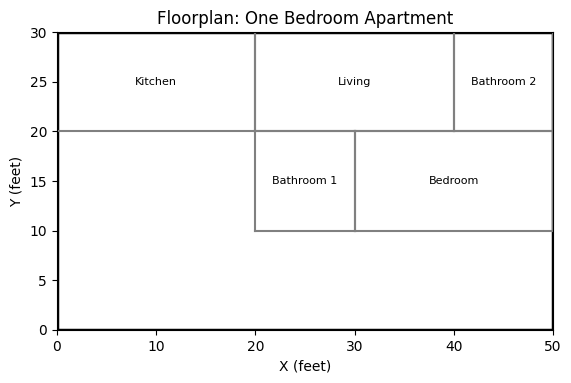

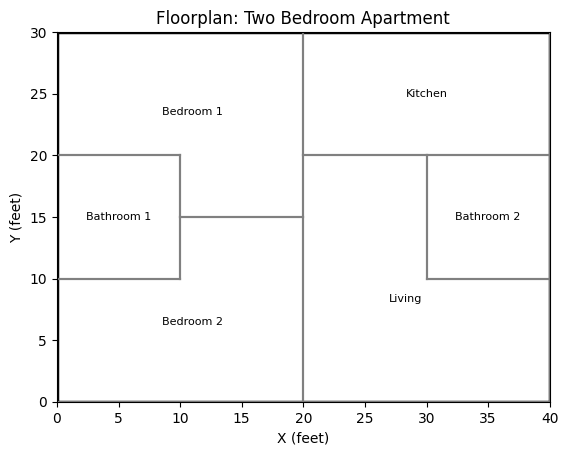


Note that floorplan 6 has a courtyard


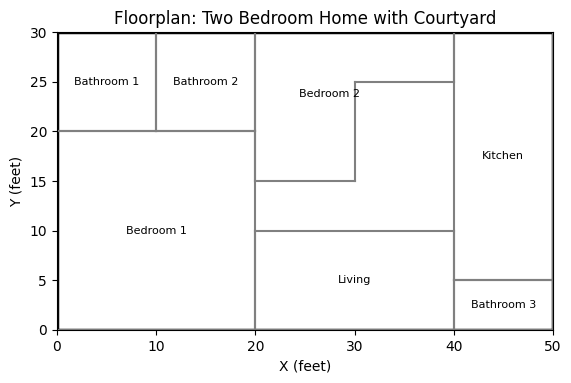

In [ ]:
plot_floorplan(floorplan_1)
print("")
plot_floorplan(floorplan_3)
print("")
print("Note that floorplan 6 has a courtyard")
plot_floorplan(floorplan_6)